<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/visualization/visualize_advanced_sampler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

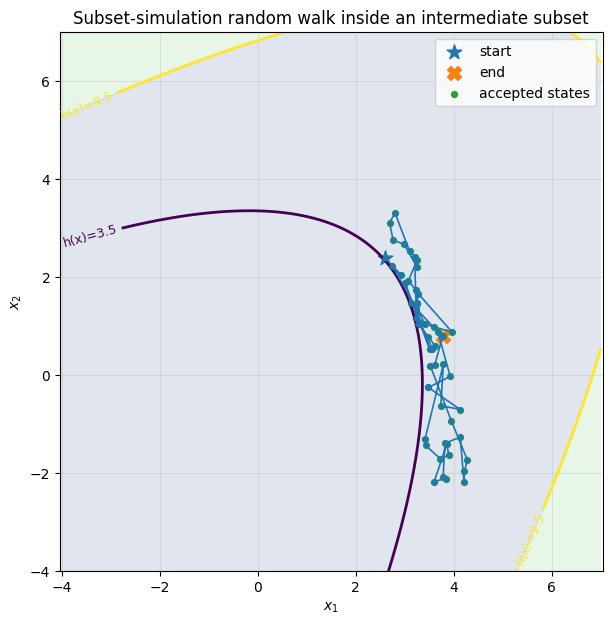

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Problem definition
# ============================================================
beta = 9.5
c = 0.1

def score(x):
    x = np.atleast_2d(x)
    return (x[:, 0] + x[:, 1]) / np.sqrt(2) + c * (x[:, 0] - x[:, 1])**2

# Failure if score(x) >= beta
threshold = 3.5   # intermediate subset level
n_steps = 140
proposal_sigma = 0.55
seed = 123

rng = np.random.default_rng(seed)

# ============================================================
# Constrained random walk (subset simulation style)
# ============================================================
x = np.array([2.6, 2.4])  # start inside h(x) >= threshold
assert score(x)[0] >= threshold

chain = [x.copy()]
accepted_flags = [True]

for _ in range(n_steps - 1):
    x_prop = x + proposal_sigma * rng.standard_normal(2)

    accepted = False
    if score(x_prop)[0] >= threshold:
        log_alpha = -0.5 * (x_prop @ x_prop - x @ x)  # target = standard normal
        if np.log(rng.random()) < min(0.0, log_alpha):
            x = x_prop
            accepted = True

    chain.append(x.copy())
    accepted_flags.append(accepted)

chain = np.array(chain)
accepted_flags = np.array(accepted_flags)

# ============================================================
# Background geometry
# ============================================================
xx = np.linspace(-4, 7, 400)
yy = np.linspace(-4, 7, 400)
X1, X2 = np.meshgrid(xx, yy)
H = (X1 + X2) / np.sqrt(2) + c * (X1 - X2)**2

plt.figure(figsize=(7, 7))

# Failure region
plt.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)

# Intermediate subset and failure boundary
cs = plt.contour(X1, X2, H, levels=[threshold, beta], linewidths=2)
plt.clabel(cs, fmt={threshold: f"h(x)={threshold}", beta: f"h(x)={beta}"}, inline=True, fontsize=9)

# Random walk path
plt.plot(chain[:, 0], chain[:, 1], marker='o', ms=3, lw=1.2)
plt.scatter(chain[0, 0], chain[0, 1], s=120, marker='*', label='start')
plt.scatter(chain[-1, 0], chain[-1, 1], s=100, marker='X', label='end')

# Accepted moves only
accepted_pts = chain[accepted_flags]
plt.scatter(accepted_pts[:, 0], accepted_pts[:, 1], s=18, label='accepted states')

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Subset-simulation random walk inside an intermediate subset")
plt.axis("equal")
plt.xlim(-4, 7)
plt.ylim(-4, 7)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

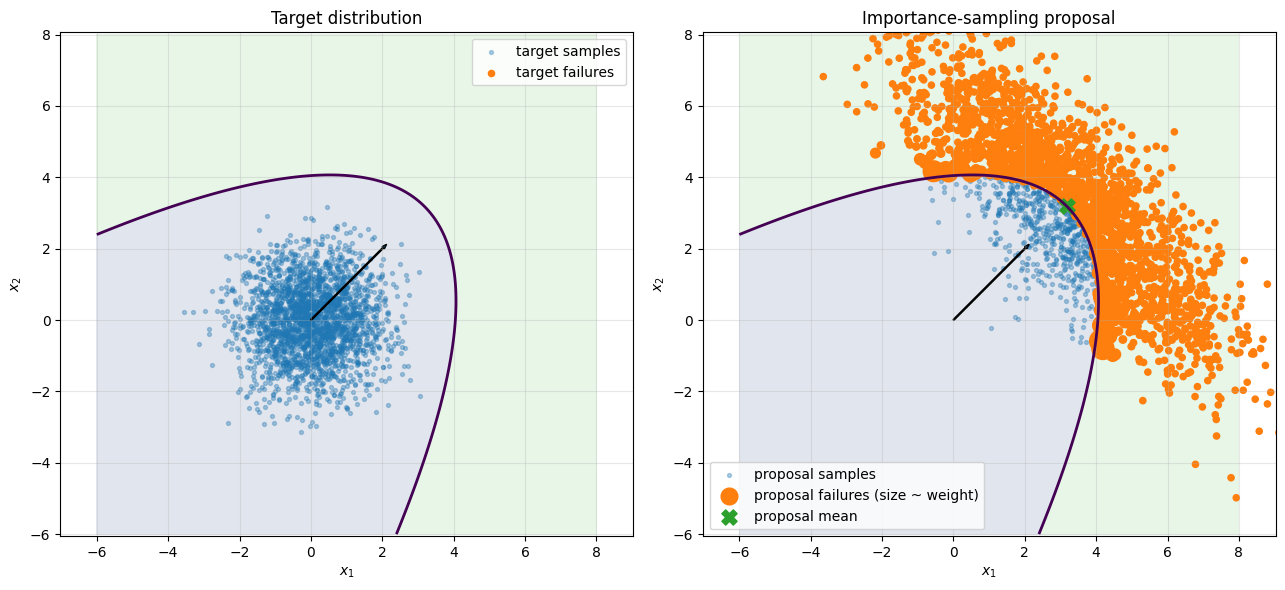

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Problem definition
# ============================================================
beta = 4.5
c = 0.1

def score(x):
    x = np.atleast_2d(x)
    return (x[:, 0] + x[:, 1]) / np.sqrt(2) + c * (x[:, 0] - x[:, 1])**2

alpha = np.array([1.0, 1.0]) / np.sqrt(2)     # important direction
v = np.array([1.0, -1.0]) / np.sqrt(2)        # orthogonal direction

seed = 123
rng = np.random.default_rng(seed)

# IS proposal in rotated coordinates
mu_t = beta
sigma_z = 3.0

N_target = 2500
N_prop = 2500

# Target samples
X_target = rng.standard_normal((N_target, 2))
fail_target = score(X_target) >= beta

# Proposal samples
t = rng.normal(loc=mu_t, scale=1.0, size=N_prop)
z = rng.normal(loc=0.0, scale=sigma_z, size=N_prop)
X_prop = np.outer(t, alpha) + np.outer(z, v)
fail_prop = score(X_prop) >= beta

# Importance weights p/q
logw_t = -mu_t * t + 0.5 * mu_t**2
logw_z = np.log(sigma_z) - 0.5 * z**2 + 0.5 * (z / sigma_z)**2
w = np.exp(logw_t + logw_z)

# ============================================================
# Background geometry
# ============================================================
xx = np.linspace(-6, 8, 400)
yy = np.linspace(-6, 8, 400)
X1, X2 = np.meshgrid(xx, yy)
H = (X1 + X2) / np.sqrt(2) + c * (X1 - X2)**2

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# -------- Left: target distribution
ax = axes[0]
ax.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)
ax.contour(X1, X2, H, levels=[beta], linewidths=2)
ax.scatter(X_target[:, 0], X_target[:, 1], s=8, alpha=0.35, label='target samples')
ax.scatter(X_target[fail_target, 0], X_target[fail_target, 1], s=20, label='target failures')
ax.arrow(0, 0, 3*alpha[0], 3*alpha[1], width=0.03, length_includes_head=True)
ax.set_title("Target distribution")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.axis("equal")
ax.set_xlim(-6, 8)
ax.set_ylim(-6, 8)
ax.grid(alpha=0.3)
ax.legend()

# -------- Right: proposal distribution
ax = axes[1]
ax.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)
ax.contour(X1, X2, H, levels=[beta], linewidths=2)
ax.scatter(X_prop[:, 0], X_prop[:, 1], s=8, alpha=0.35, label='proposal samples')

if fail_prop.any():
    sizes = 20 + 250 * (w[fail_prop] / w[fail_prop].max())
    ax.scatter(X_prop[fail_prop, 0], X_prop[fail_prop, 1], s=sizes, label='proposal failures (size ~ weight)')

proposal_mean = mu_t * alpha
ax.scatter([proposal_mean[0]], [proposal_mean[1]], s=120, marker='X', label='proposal mean')
ax.arrow(0, 0, 3*alpha[0], 3*alpha[1], width=0.03, length_includes_head=True)
ax.set_title("Importance-sampling proposal")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.axis("equal")
ax.set_xlim(-6, 8)
ax.set_ylim(-6, 8)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

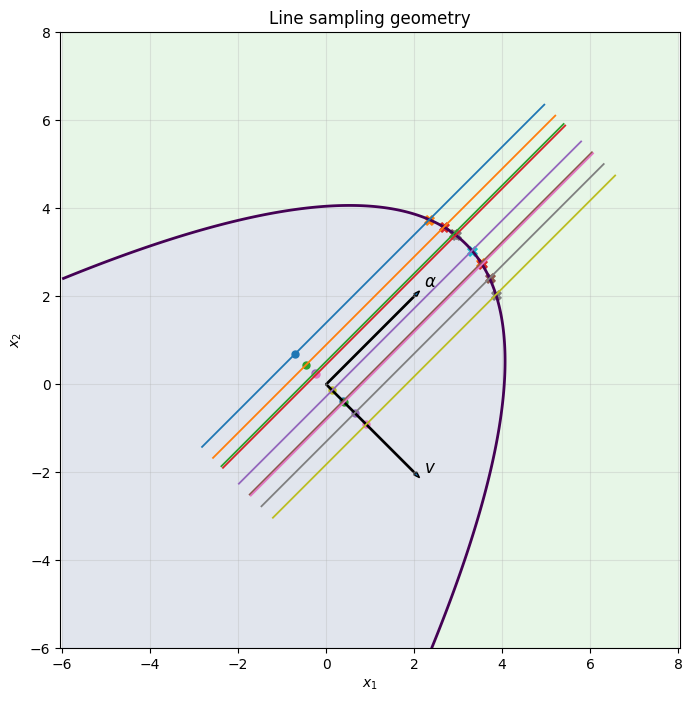

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Problem definition
# ============================================================
beta = 4.5
c = 0.1

alpha = np.array([1.0, 1.0]) / np.sqrt(2)     # important direction
v = np.array([1.0, -1.0]) / np.sqrt(2)        # orthogonal direction

seed = 123
rng = np.random.default_rng(seed)

# In rotated coordinates:
# x = t * alpha + z * v
# failure when t + 2 c z^2 >= beta
z_vals = np.sort(rng.normal(0, 1, 9))
t_grid = np.linspace(-3, 8, 400)

# ============================================================
# Background geometry
# ============================================================
xx = np.linspace(-6, 8, 400)
yy = np.linspace(-6, 8, 400)
X1, X2 = np.meshgrid(xx, yy)
H = (X1 + X2) / np.sqrt(2) + c * (X1 - X2)**2

plt.figure(figsize=(8, 8))
plt.contourf(X1, X2, H >= beta, levels=[-0.5, 0.5, 1.5], alpha=0.15)
plt.contour(X1, X2, H, levels=[beta], linewidths=2)

for z in z_vals:
    # line: x(t) = t alpha + z v
    X_line = np.outer(t_grid, alpha) + np.outer(np.full_like(t_grid, z), v)
    plt.plot(X_line[:, 0], X_line[:, 1], lw=1.3)

    # point where the line hits the failure boundary
    t_star = beta - 2 * c * z**2
    x_star = t_star * alpha + z * v
    x_base = z * v

    plt.scatter([x_base[0]], [x_base[1]], s=25)   # base point on perpendicular direction
    plt.scatter([x_star[0]], [x_star[1]], s=45, marker='X')  # entry point into failure

# Important and orthogonal directions
plt.arrow(0, 0, 3*alpha[0], 3*alpha[1], width=0.03, length_includes_head=True)
plt.arrow(0, 0, 3*v[0], 3*v[1], width=0.03, length_includes_head=True)

plt.text(3*alpha[0] + 0.1, 3*alpha[1] + 0.1, r"$\alpha$", fontsize=12)
plt.text(3*v[0] + 0.1, 3*v[1] + 0.1, r"$v$", fontsize=12)

plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Line sampling geometry")
plt.axis("equal")
plt.xlim(-6, 8)
plt.ylim(-6, 8)
plt.grid(alpha=0.3)
plt.show()